# Manufacturing Quality Analysis: What Drives Phone-Case Drop-Test Failures?

**Author: Niveditha Bhoja Raj Shetty**  ·  *Python · pandas · seaborn · exploratory data analysis*

---

## Project overview

A manufacturer produces cell-phone cases on **three injection-molding machines**, using plastic pellets sourced from **two suppliers**. Each finished case is put through a **drop test** that it either passes or fails. Roughly **1 in 3 cases fails**, and the business wants to know **why** — so it can target the right machine, supplier, or process setting instead of guessing.

This project merges four separate data sources (three machine logs, a supplier/material file, and drop-test results) into a single analytical dataset, then explores which factors are associated with failure.

## Key findings

- **Supplier is the strongest lever.** Cases made from **Supplier A** material fail **33%** of the time versus **25%** for Supplier B — the largest gap of any factor examined.
- **Material density matters.** Failed cases have **lower average density** (9.61) than passed cases (9.78), and Supplier A's material is both lower-density and less consistent.
- **Machines are roughly equivalent.** Failure rates sit in a tight **28–32%** band across all three machines, so the machines themselves are not the primary driver.
- **One process setting stands out.** Operating variable **`x4`** runs higher on failed cases, making it the most promising process parameter to investigate.

## The data

| Source | Rows | What it contains |
|---|---|---|
| Machine logs (×3) | ~14,300 combined | Per-unit operating variables `x1`–`x4`, batch, sequence id |
| Supplier / material file | 50 batches | Which supplier provided each batch, and its plastic **density** |
| Drop-test results | 1,412 tests | Pass / fail outcome (`Result`; 1 = fail) per unit |

The sections below walk through data validation, exploration of each source, how they were joined, and the failure analysis that produced the findings above.

## Setup

The analysis uses `pandas` for data manipulation and `seaborn`/`matplotlib` for visualization.

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Machine production data

The three machines each write their own log. The first step is to load all three and confirm they share a consistent schema before combining them.

In [84]:
# Define the files for the 3 machine level CSV files

file_m01 = 'midterm_machine_01.csv'

file_m02 = 'midterm_machine_02.csv'

file_m03 = 'midterm_machine_03.csv'

In [85]:
# Read in the CSV files and name them accordingly

m01_df = pd.read_csv(file_m01)

m02_df = pd.read_csv(file_m02)

m03_df = pd.read_csv(file_m03)

### Data-quality check

Before trusting any dataset it's worth confirming its shape, column types, cardinality, and missing values.

In [86]:
print(m01_df.shape)        #rows and columns in machine01 data set
print(m02_df.shape)        #rows and columns in machine02 data set
print(m03_df.shape)        #rows and columns in machine03 data set

(5152, 7)
(5119, 7)
(4458, 7)


In [87]:
m01_df.info()              #names and data types for each column  of machine01 data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5152 entries, 0 to 5151
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      5152 non-null   object 
 1   Batch   5152 non-null   int64  
 2   s_id    5152 non-null   int64  
 3   x1      5152 non-null   float64
 4   x2      5152 non-null   float64
 5   x3      5152 non-null   float64
 6   x4      5152 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 281.9+ KB


In [88]:
m02_df.info()              #names and data types for each column  of machine02 data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5119 entries, 0 to 5118
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      5119 non-null   object 
 1   Batch   5119 non-null   int64  
 2   s_id    5119 non-null   int64  
 3   x1      5119 non-null   float64
 4   x2      5119 non-null   float64
 5   x3      5119 non-null   float64
 6   x4      5119 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 280.1+ KB


In [89]:
m03_df.info()            #names and data types for each column of machine03 data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4458 entries, 0 to 4457
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      4458 non-null   object 
 1   Batch   4458 non-null   int64  
 2   s_id    4458 non-null   int64  
 3   x1      4458 non-null   float64
 4   x2      4458 non-null   float64
 5   x3      4458 non-null   float64
 6   x4      4458 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 243.9+ KB


In [90]:
print(m01_df.nunique())     #unique values in each column of machine01 data set
print(m02_df.nunique())     #unique values in each column of machine02 data set
print(m03_df.nunique())     #unique values in each column of machine03 data set

ID       5152
Batch      50
s_id      149
x1       5152
x2       5152
x3       5152
x4       5152
dtype: int64
ID       5119
Batch      50
s_id      133
x1       5119
x2       5119
x3       5119
x4       5119
dtype: int64
ID       4458
Batch      41
s_id      141
x1       4458
x2       4458
x3       4458
x4       4458
dtype: int64


In [91]:
print(m01_df.isna().sum())        #missing values in each column of machine01 data set
print(m02_df.isna().sum())        #missing values in each column of machine02 data set
print(m03_df.isna().sum())        #missing values in each column of machine03 data set

ID       0
Batch    0
s_id     0
x1       0
x2       0
x3       0
x4       0
dtype: int64
ID       0
Batch    0
s_id     0
x1       0
x2       0
x3       0
x4       0
dtype: int64
ID       0
Batch    0
s_id     0
x1       0
x2       0
x3       0
x4       0
dtype: int64


**Finding:** All three machine logs share the same 7 columns with identical data types, and none contain missing values — so they can be safely stacked into one table.

### Combining the three machines

Each machine's rows are tagged with a `machine_id` (1, 2, or 3) and concatenated into a single `machine_df`, so machine of origin is preserved after merging.

In [92]:
# Concatenate the 3 DataFrames into a single DataFrame which includes the `machine_id` variable

m01_df["machine_id"] = 1
m02_df["machine_id"] = 2
m03_df["machine_id"] = 3
machine_df = pd.concat([m01_df, m02_df, m03_df], ignore_index = True)
machine_df.head()      #verifying what the combined data set looks like

,ID,Batch,s_id,x1,x2,x3,x4,machine_id
0,B001-M01-S001,1,1,50.117118,102.167346,22.067812,13.889524,1
1,B001-M01-S002,1,2,46.887333,112.266102,23.197330,13.064709,1
2,B001-M01-S003,1,3,50.132744,103.674908,22.319933,13.647482,1
3,B001-M01-S004,1,4,48.501042,107.143156,22.162947,14.077758,1
4,B001-M01-S005,1,5,49.690442,102.120283,22.248696,13.728666,1


In [93]:
machine_df.shape

(14729, 8)

### Batches produced per machine

In [94]:
machine_df.groupby("machine_id")["Batch"].nunique()

machine_id
1    50
2    50
3    41
Name: Batch, dtype: int64

**Finding:** Machines 1 and 2 each ran 50 distinct batches; Machine 3 ran 41 — Machine 3 simply produced somewhat less volume.

### Distribution of each variable

Each column is visualized using a chart appropriate to its type — bar charts for categorical fields (`machine_id`, `Batch`) and histograms for the continuous operating variables.

In [95]:
machine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14729 entries, 0 to 14728
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          14729 non-null  object 
 1   Batch       14729 non-null  int64  
 2   s_id        14729 non-null  int64  
 3   x1          14729 non-null  float64
 4   x2          14729 non-null  float64
 5   x3          14729 non-null  float64
 6   x4          14729 non-null  float64
 7   machine_id  14729 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 920.7+ KB


In [96]:
machine_df.nunique()

ID            14729
Batch            50
s_id            149
x1            14729
x2            14729
x3            14729
x4            14729
machine_id        3
dtype: int64

*Approach: `machine_id` and `Batch` are treated as categorical (discrete labels), so they're shown as count plots.*

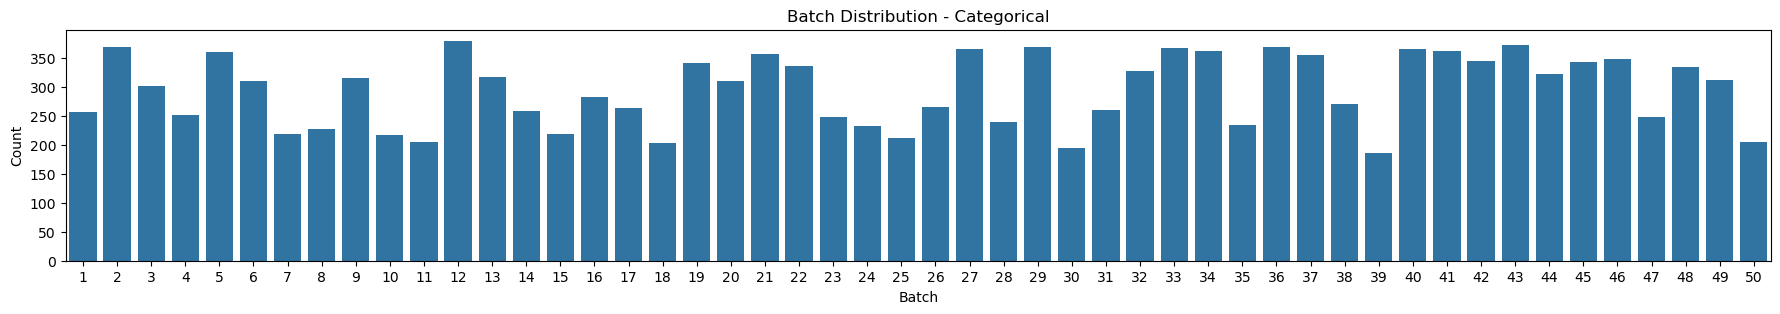

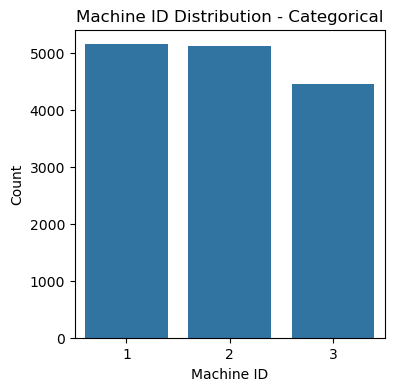

In [97]:
fig, ax = plt.subplots(figsize = (22,3))
sns.countplot(data=machine_df, x="Batch", ax=ax)
ax.set_xlabel("Batch")
ax.set_ylabel("Count")
ax.set_title("Batch Distribution - Categorical")
plt.show()

fig, ax = plt.subplots(figsize = (4,4))
sns.countplot(data=machine_df, x="machine_id", ax=ax)
ax.set_xlabel("Machine ID")
ax.set_ylabel("Count")
ax.set_title("Machine ID Distribution - Categorical")
plt.show()


**Finding:** Batch volumes are fairly even (roughly 200–350 units each, no single dominant batch). Machines 1 and 2 each produced ~5,000 units; Machine 3 produced ~4,300.

*Approach: `x1`–`x4` are continuous operating variables, shown as histograms with KDE overlays; `s_id` (sequence id) is shown separately.*

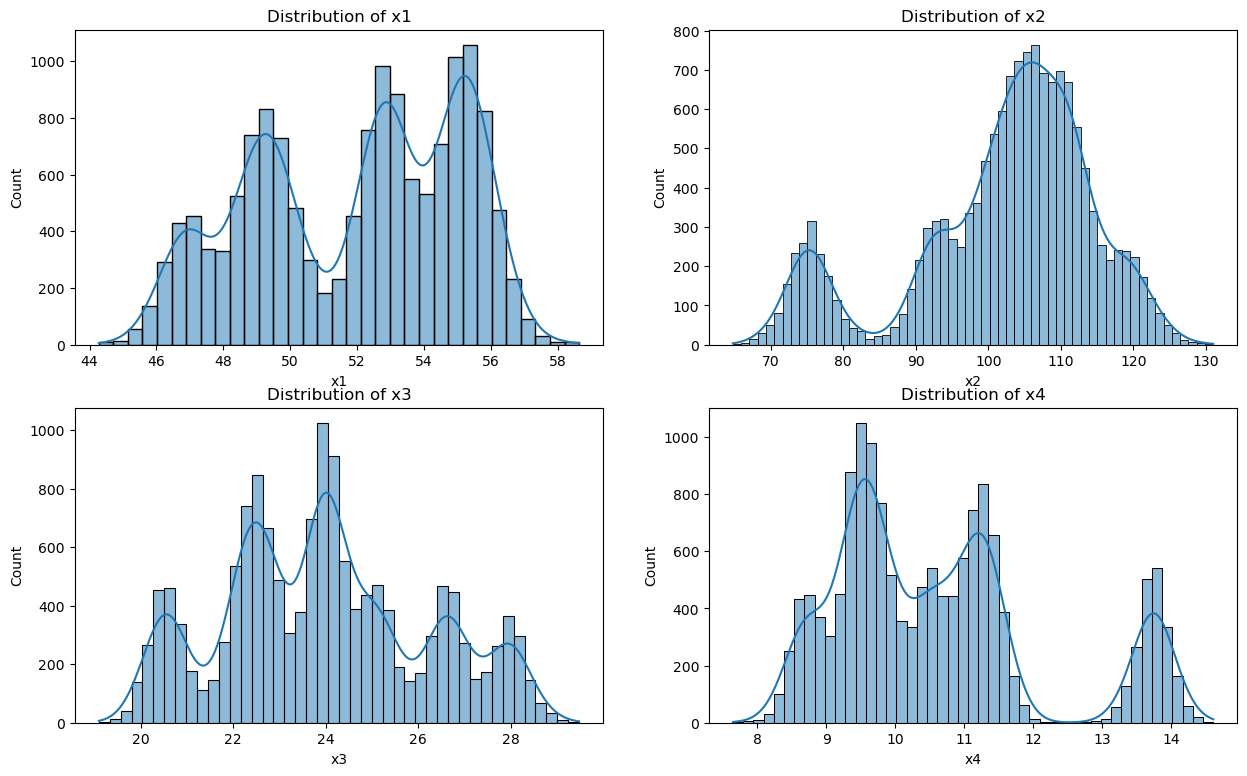

In [98]:
fig, axes = plt.subplots(2,2, figsize=(15,9))
sns.histplot(data=machine_df, x="x1", kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribution of x1")

sns.histplot(data=machine_df, x="x2", kde=True, ax=axes[0,1])
axes[0,1].set_title("Distribution of x2")

sns.histplot(data=machine_df, x="x3", kde=True, ax=axes[1,0])
axes[1,0].set_title("Distribution of x3")

sns.histplot(data=machine_df, x="x4", kde=True, ax=axes[1,1])
axes[1,1].set_title("Distribution of x4")

plt.show()

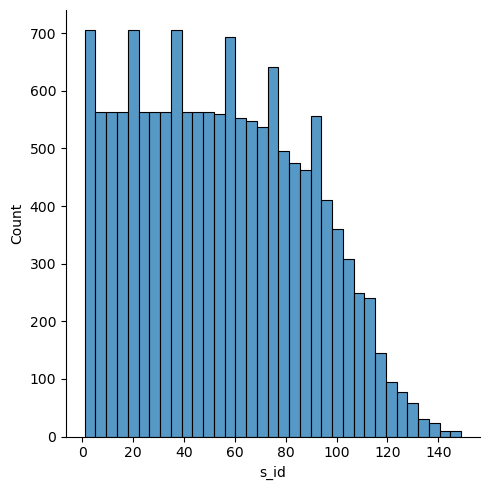

In [99]:
sns.displot(data=machine_df, x="s_id", kind="hist")
plt.show()

**Finding:** Because the data pools all three machines, the operating variables show multiple peaks. The sequence id tapers off, meaning higher sequence numbers appear less often.

### Do the machines behave differently?

If the machines ran at systematically different settings, that could explain quality differences. Boxplots compare the operating variables across machines.

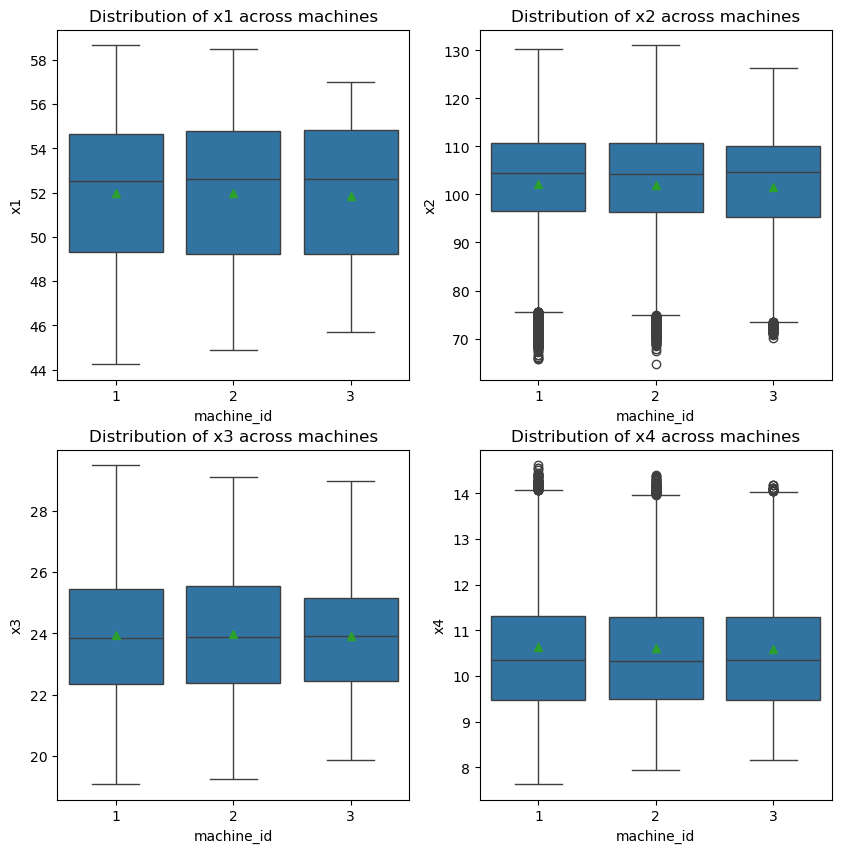

In [100]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
sns.boxplot(data=machine_df, x="machine_id", y="x1", ax=axes[0,0], showmeans=True)
axes[0,0].set_title("Distribution of x1 across machines")
sns.boxplot(data=machine_df, x="machine_id", y="x2", ax=axes[0,1], showmeans=True)
axes[0,1].set_title("Distribution of x2 across machines")
sns.boxplot(data=machine_df, x="machine_id", y="x3", ax=axes[1,0], showmeans=True)
axes[1,0].set_title("Distribution of x3 across machines")
sns.boxplot(data=machine_df, x="machine_id", y="x4", ax=axes[1,1], showmeans=True)
axes[1,1].set_title("Distribution of x4 across machines")
plt.show()

**Finding:** The operating variables do **not** vary meaningfully across machines — medians, means, and quartiles line up closely (with a few outliers in `x2` and `x4`). The three machines are effectively running the same process.

### Mean operating value per machine

In [101]:
machine_df.groupby("machine_id")[["x1", "x2", "x3", "x4"]].mean()

,x1,x2,x3,x4
machine_id,,,,
1,51.998218,102.207011,23.947216,10.628436
2,51.989377,101.998905,23.982312,10.605275
3,51.857672,101.650057,23.927679,10.602371


## 2. Supplier & material data

Each batch of plastic pellets comes from one of two suppliers and has a measured **density**. This file lets us connect material properties back to the units produced.

In [102]:
# define the batch supplier file
batch_file = 'midterm_supplier.csv'

In [103]:
# read in the batch supplier data set

batch_df = pd.read_csv(batch_file)

In [104]:
batch_df.head()   #to verify

,Batch,Supplier,Density
0,1,B,10.388587
1,2,A,9.296880
2,3,A,9.565636
3,4,B,10.005387
4,5,A,9.339177


### Data-quality check

In [105]:
batch_df.shape    

(50, 3)

In [106]:
batch_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Batch     50 non-null     int64  
 1   Supplier  50 non-null     object 
 2   Density   50 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.3+ KB


In [107]:
batch_df.nunique()

Batch       50
Supplier     2
Density     50
dtype: int64

In [108]:
batch_df.isna().sum()

Batch       0
Supplier    0
Density     0
dtype: int64

**Finding:** The supplier file holds 50 batches × 3 columns (`Batch`, `Supplier`, `Density`), one row per batch, with no missing values. `Supplier` takes two values (A, B).

### Distribution of supplier variables

*Approach: `Batch` and `Supplier` are categorical (count plots); `Density` is continuous (histogram).*

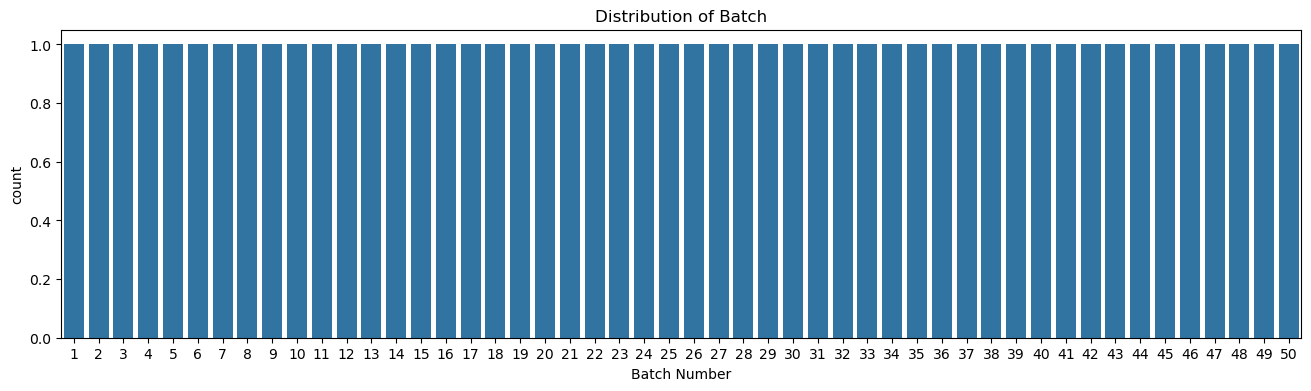

In [109]:
fig, ax = plt.subplots(figsize = (16,4))
sns.countplot(data=batch_df, x="Batch", ax=ax)
ax.set_xlabel("Batch Number")
ax.set_title("Distribution of Batch")
plt.show()

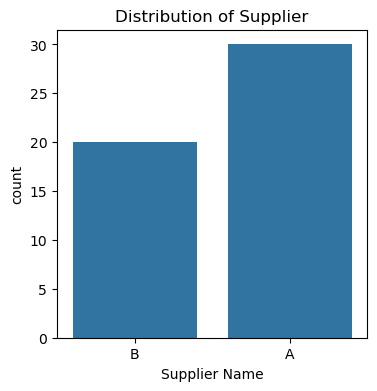

In [110]:
fig, ax = plt.subplots(figsize= (4,4))
sns.countplot(data=batch_df, x="Supplier", ax=ax)
ax.set_title("Distribution of Supplier")
ax.set_xlabel("Supplier Name")
plt.show()

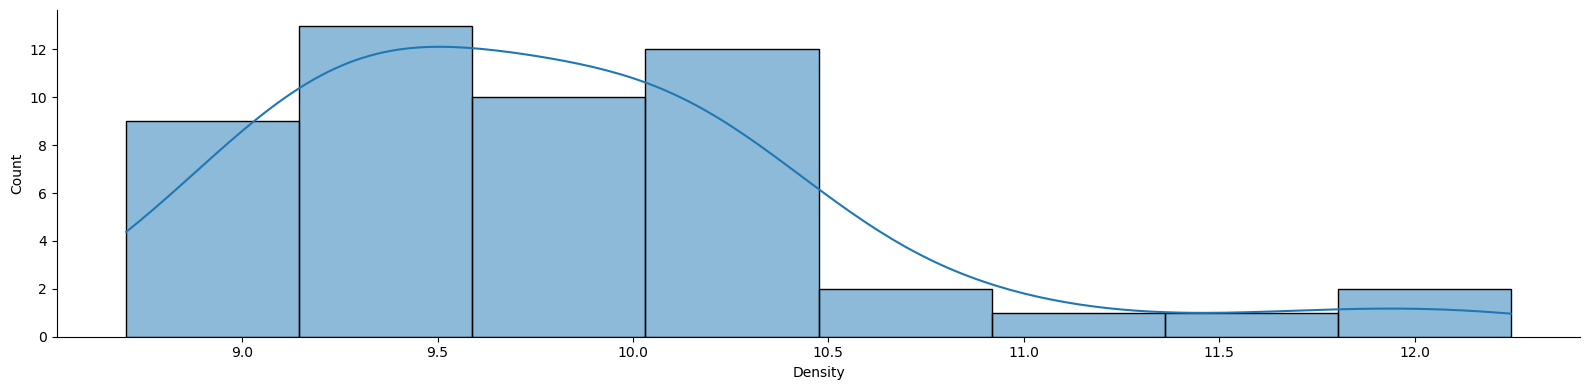

In [111]:
sns.displot(data=batch_df, x="Density", kind="hist", kde=True, height=4, aspect=4)
plt.show()

**Finding:** Supplier A provided ~30 batches, Supplier B ~20. The density distribution is right-skewed — lower-density plastic is more common than high-density.

### Does material density depend on the supplier?

Density is a plausible driver of durability, so it's worth checking whether the two suppliers differ.

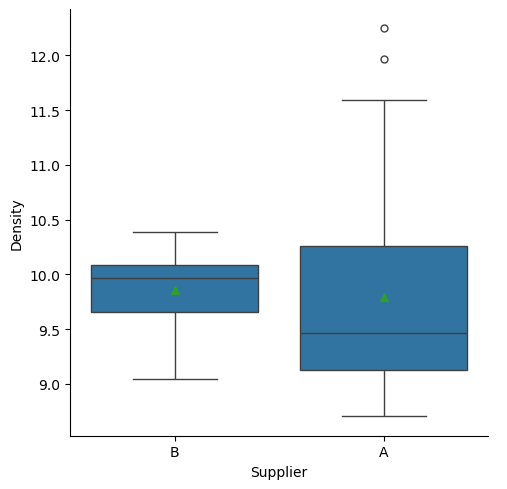

In [112]:
sns.catplot(data=batch_df, x="Supplier", y="Density", kind="box", showmeans=True)
plt.show()

**Finding:** The two suppliers have similar **mean** density (~9.8), but Supplier B is far more **consistent** (tighter spread), while Supplier A's density is more variable and includes outliers. Consistency, not average, is where they diverge.

### Linking materials to production

The supplier data is merged into the machine data on `Batch`, giving each produced unit its material properties (`dfa`).

In [113]:
# merge the batch supplier data set with the (concatenated) machine data set

dfa = pd.merge(batch_df, machine_df, on = "Batch", how="inner")

In [114]:
dfa.shape    #to verify

(14729, 10)

### Do suppliers affect machine operating conditions?

A quick check that supplier choice isn't confounded with how the machines were run.

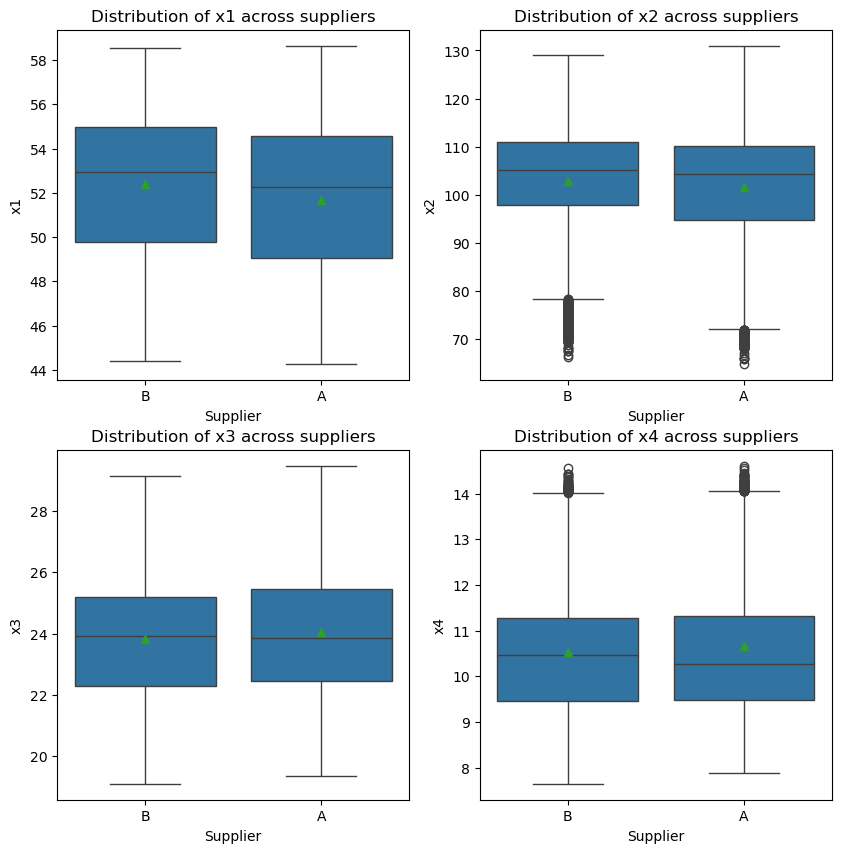

In [115]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
sns.boxplot(data= dfa, x="Supplier", y="x1", ax=axes[0,0], showmeans=True)
axes[0,0].set_title("Distribution of x1 across suppliers")

sns.boxplot(data= dfa, x="Supplier", y="x2", ax=axes[0,1], showmeans=True)
axes[0,1].set_title("Distribution of x2 across suppliers")

sns.boxplot(data= dfa, x="Supplier", y="x3", ax=axes[1,0], showmeans=True)
axes[1,0].set_title("Distribution of x3 across suppliers")

sns.boxplot(data= dfa, x="Supplier", y="x4", ax=axes[1,1], showmeans=True)
axes[1,1].set_title("Distribution of x4 across suppliers")

plt.show()

**Finding:** Operating variables `x1`–`x4` are essentially the same across both suppliers (only minor differences). So supplier effects on quality, if any, come from the **material** itself rather than different machine settings.

## 3. Drop-test results

Each tested unit has a pass/fail outcome. This is the target we ultimately want to explain.

In [64]:
# define the test data set file name
test_file = 'midterm_test.csv'

In [65]:
# read in the test data set

test_df = pd.read_csv(test_file)

In [66]:
test_df.head()  #to verify

,ID,test_group_id,Result
0,B001-M01-S056,A-0,1
1,B001-M01-S002,A-0,1
2,B001-M01-S049,A-0,1
3,B001-M01-S030,A-0,0
4,B001-M01-S048,A-0,1


### Data-quality check

In [67]:
test_df.shape

(1412, 3)

In [68]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             1412 non-null   object
 1   test_group_id  1412 non-null   object
 2   Result         1412 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 33.2+ KB


In [69]:
test_df.nunique()

ID               1412
test_group_id     141
Result              2
dtype: int64

In [70]:
test_df.isna().sum()

ID               0
test_group_id    0
Result           0
dtype: int64

**Finding:** 1,412 tests × 3 columns (`ID`, `test_group_id`, `Result`), no missing values. `Result` is binary (1 = fail), and tests are organized into 141 test groups.

### Pass / fail distribution

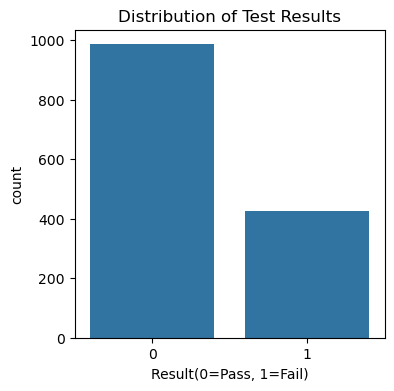

In [71]:
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(data=test_df, x="Result", ax=ax)
ax.set_title("Distribution of Test Results")
ax.set_xlabel("Result(0=Pass, 1=Fail)")
plt.show()

**Finding:** About **980 units passed** and **420 failed** — an overall failure rate near **30%**, high enough to be worth explaining.

In [72]:
test_df["test_group_id"].value_counts().describe()

count    141.000000
mean      10.014184
std        1.945639
min        5.000000
25%        9.000000
50%       10.000000
75%       11.000000
max       14.000000
Name: count, dtype: float64

**Finding:** Tests are evenly distributed across the 141 groups — 5 to 14 units per group, averaging ~10 — so no group dominates the results.

### Building the master dataset

The drop-test results are joined onto the combined machine + supplier table (`dfa`) to create `dfb`, the single analytical dataset linking each tested unit to its machine, supplier, material density, and operating variables.

In [73]:
print(dfa.info())
print(test_df.info())    #recall to identify the key for merging

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14729 entries, 0 to 14728
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Batch       14729 non-null  int64  
 1   Supplier    14729 non-null  object 
 2   Density     14729 non-null  float64
 3   ID          14729 non-null  object 
 4   s_id        14729 non-null  int64  
 5   x1          14729 non-null  float64
 6   x2          14729 non-null  float64
 7   x3          14729 non-null  float64
 8   x4          14729 non-null  float64
 9   machine_id  14729 non-null  int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 1.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             1412 non-null   object
 1   test_group_id  1412 non-null   object
 2   Result         1412 non-null   int64 
dtypes: int

In [74]:
# merge test_df with the dfa object

dfb = pd.merge(test_df, dfa, on="ID")
dfb.head()    #to verify

,ID,test_group_id,Result,Batch,Supplier,Density,s_id,x1,x2,x3,x4,machine_id
0,B001-M01-S056,A-0,1,1,B,10.388587,56,49.215485,105.647327,21.410531,14.154576,1
1,B001-M01-S002,A-0,1,1,B,10.388587,2,46.887333,112.266102,23.197330,13.064709,1
2,B001-M01-S049,A-0,1,1,B,10.388587,49,49.125629,112.323042,22.874947,13.743788,1
3,B001-M01-S030,A-0,0,1,B,10.388587,30,48.306819,109.445722,22.910858,13.839830,1
4,B001-M01-S048,A-0,1,1,B,10.388587,48,50.564504,109.184587,22.083064,13.954942,1


In [75]:
dfb.shape

(1412, 12)

**Finding:** The default (inner) join yields 1,412 rows — every drop-tested unit is matched to its full production record.

## 4. What drives drop-test failures?

With everything joined, we can compare failure rates across each candidate factor: machine, supplier, material density, and operating variables.

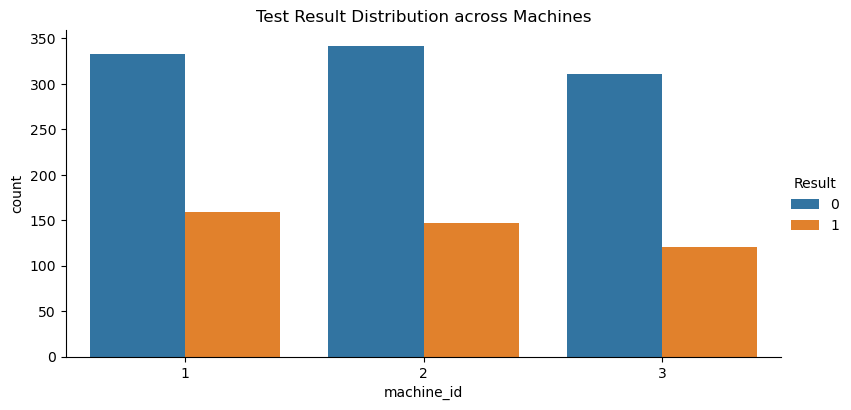

In [76]:
sns.catplot(data=dfb, x="machine_id", hue="Result", kind="count", height=4, aspect=2)
plt.title("Test Result Distribution across Machines") 
plt.show()

In [77]:
dfb.groupby("machine_id")["Result"].mean()   
#since the only values in the Result column are 1s (fails) and 0s (passes), the mean should give the failure rate.

machine_id
1    0.323171
2    0.300613
3    0.278422
Name: Result, dtype: float64

**Finding — machine:** Failure rates are close across machines: **Machine 1 = 32.3%**, **Machine 2 = 30.1%**, **Machine 3 = 27.8%**. Machine 1 is marginally worst, but no machine stands out as the culprit.

### Failure rate by supplier

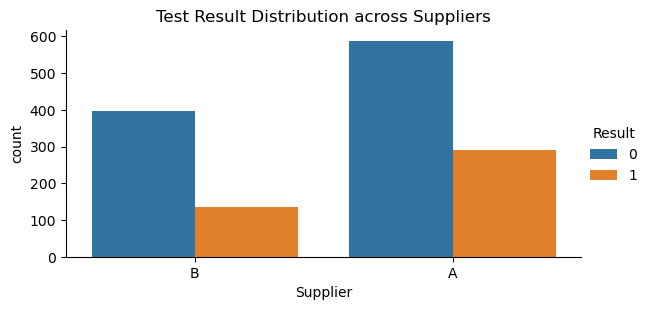

In [78]:
sns.catplot(data=dfb, x="Supplier", hue="Result", kind="count", height=3, aspect=2)
plt.title("Test Result Distribution across Suppliers") 
plt.show()

In [79]:
dfb.groupby("Supplier")["Result"].mean()   

Supplier
A    0.330296
B    0.254682
Name: Result, dtype: float64

**Finding — supplier:** A clear gap. **Supplier A fails 33.0%** of the time versus **25.5%** for Supplier B. Material source is the single biggest differentiator found.

### Failure vs. material density

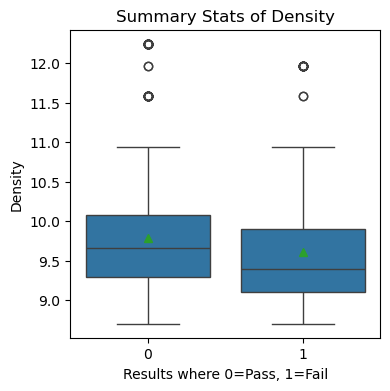

In [80]:
fig, ax = plt.subplots(figsize=(4,4))
sns.boxplot(data=dfb, x="Result", y="Density", ax=ax, showmeans = True)
ax.set_xlabel("Results where 0=Pass, 1=Fail")
ax.set_title("Summary Stats of Density")
plt.show()


**Finding — density:** Passed units tend to have slightly **higher** density.

In [81]:
dfb.groupby("Result").agg(
    avg = ("Density", "mean"),
    sem = ("Density", "sem")
)

,avg,sem
Result,,
0,9.783150,0.023381
1,9.614393,0.033871


**Finding — density:** Passed units average higher density than failed units; the failed group also carries slightly more uncertainty (higher standard error). Lower density is associated with failure — consistent with Supplier A's lower, less-consistent density.

### Failure vs. operating variables

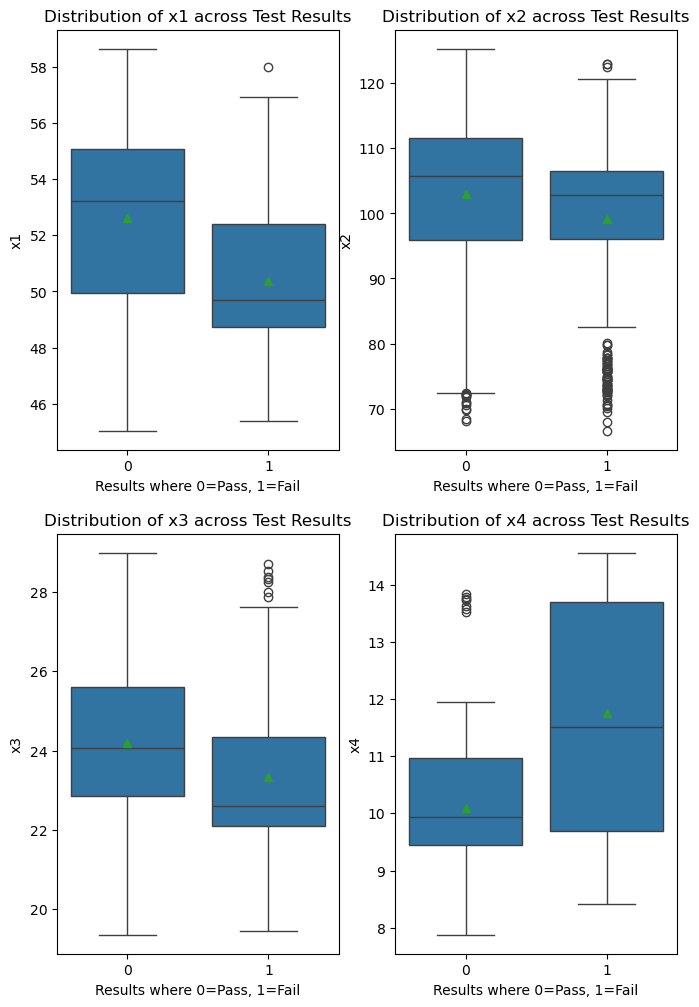

In [82]:
fig, ax = plt.subplots(2,2, figsize=(8,12))
sns.boxplot(data=dfb, x="Result", y="x1", showmeans =True, ax=ax[0,0])
ax[0,0].set_xlabel("Results where 0=Pass, 1=Fail")
ax[0,0].set_title("Distribution of x1 across Test Results")

sns.boxplot(data=dfb, x="Result", y="x2", showmeans =True, ax=ax[0,1])
ax[0,1].set_xlabel("Results where 0=Pass, 1=Fail")
ax[0,1].set_title("Distribution of x2 across Test Results")

sns.boxplot(data=dfb, x="Result", y="x3", showmeans =True, ax=ax[1,0])
ax[1,0].set_xlabel("Results where 0=Pass, 1=Fail")
ax[1,0].set_title("Distribution of x3 across Test Results")

sns.boxplot(data=dfb, x="Result", y="x4", showmeans =True, ax=ax[1,1])
ax[1,1].set_xlabel("Results where 0=Pass, 1=Fail")
ax[1,1].set_title("Distribution of x4 across Test Results")
plt.show()


**Finding — process settings:** `x1`, `x2`, and `x3` skew toward **passing** units, but **`x4` skews toward failing** units — higher `x4` values are associated with drop-test failure. `x4` is the operating parameter most worth investigating.

## Conclusions

The analysis points to four associations with drop-test failure, in order of strength:

1. **Supplier (strongest).** Supplier A's cases fail at **33%** vs. **25%** for Supplier B — a ~8-point gap driven by material, not machine settings.
2. **Material density.** Lower-density plastic is associated with failure (failed ≈ 9.61, passed ≈ 9.78), and Supplier A's material is both lower-density and less consistent.
3. **Operating variable `x4`.** Higher `x4` values track with failures, unlike `x1`–`x3`.
4. **Machine (weakest).** All three machines fail at a similar 28–32% rate; Machine 1 is marginally worst but not a primary driver.

### Recommended actions

- **Audit Supplier A** on density consistency, or shift volume toward Supplier B, and re-test the failure rate.
- **Add an incoming-material density spec** (minimum threshold) since low density tracks with failure.
- **Investigate the `x4` setting** with process engineers as the most promising machine-side lever.
- Deprioritize machine-level changes — the machines are effectively equivalent.

### Skills demonstrated

Data validation and cleaning · multi-source joins/merges (`pandas.merge`, `concat`) · grouped aggregation · choosing visualizations by data type · translating exploratory findings into business recommendations.